# 📊 Group 13 — Interest Rate Swap Valuation

---
## 1. Background & Theory

### 1.1 What is an Interest Rate Swap?

An **Interest Rate Swap (IRS)** is an over-the-counter (OTC) derivative contract in which two counterparties agree to exchange a sequence of cash flows over a specified period. The most common and vanilla form is the **plain-vanilla fixed-for-floating swap**, in which:

| Party | Pays | Receives |
|---|---|---|
| **Fixed-Rate Payer** | Fixed coupon on notional | Floating (LIBOR / SOFR) on notional |
| **Floating-Rate Payer** | Floating (LIBOR / SOFR) on notional | Fixed coupon on notional |

> 📌 **No notional principal is exchanged** — only the net difference between the fixed and floating cash flows changes hands at each payment date.

---

### 1.2 Why Do Firms Use Interest Rate Swaps?

* **Hedging**: A firm with floating-rate debt can swap into a fixed rate to eliminate interest-rate uncertainty.
* **Speculation**: A trader who expects rates to rise will enter as a fixed-rate payer (benefits if rates rise above the fixed rate).
* **Comparative Advantage**: Two firms may each have comparative advantages in different segments of the credit market, and a swap allows both to borrow at a lower total cost.

---

### 1.3 Mathematical Framework

Let:
* $N$ = notional principal
* $K$ = fixed swap rate (annualised)
* $\alpha_i$ = day-count fraction for period $i$ (e.g., 0.5 for semi-annual)
* $f_i$ = simply-compounded forward rate for period $[T_{i-1}, T_i]$
* $P(0, T_i)$ = discount factor from today to time $T_i$

#### Fixed Leg PV:
$$
PV_{\text{fixed}} = N \cdot K \cdot \sum_{i=1}^{n} \alpha_i \cdot P(0, T_i)
$$

#### Floating Leg PV:
The floating leg can be valued as:
$$
PV_{\text{float}} = N \cdot \sum_{i=1}^{n} \alpha_i \cdot f_i \cdot P(0, T_i)
$$

Where the forward rate between $T_{i-1}$ and $T_i$ is:
$$
f_i = \frac{1}{\alpha_i} \left( \frac{P(0, T_{i-1})}{P(0, T_i)} - 1 \right)
$$

#### Swap Value (from fixed-rate payer's perspective):
$$
V_{\text{swap}} = PV_{\text{float}} - PV_{\text{fixed}}
$$

A **positive** value means the swap is **in-the-money** for the fixed-rate payer (floating receipts exceed fixed payments). A **negative** value means it is **out-of-the-money**.

#### Par (Fair) Swap Rate:
The rate $K^*$ that makes the swap worth exactly zero at inception:
$$
K^* = \frac{\sum_{i=1}^{n} \alpha_i \cdot f_i \cdot P(0, T_i)}{\sum_{i=1}^{n} \alpha_i \cdot P(0, T_i)}
$$

---

### 1.4 Discount Factors from Zero Rates

Given a continuously-compounded zero rate $r(T)$ for maturity $T$, the discount factor is:
$$
P(0, T) = e^{-r(T) \cdot T}
$$

We will build a **zero curve** using bootstrap interpolation from market swap rates and deposit rates.

---

### 1.5 DV01 — Dollar Value of a Basis Point

**DV01** measures how much the swap's value changes for a 1 basis point (0.01%) parallel shift in the yield curve:
$$
\text{DV01} = \frac{\partial V_{\text{swap}}}{\partial r} \times 0.0001
$$

It is numerically approximated as:
$$
\text{DV01} \approx \frac{V(r + 1\text{bp}) - V(r - 1\text{bp})}{2}
$$


---
## 2. Project Setup & Imports

We use standard scientific Python libraries:
* `numpy` — numerical arrays and math
* `pandas` — tabular data (cash flow schedules)
* `matplotlib` & `seaborn` — visualisations
* `scipy` — interpolation for the yield curve

No exotic packages are required — everything below is available in a standard Anaconda environment.

In [27]:
import numpy as np                          
import pandas as pd                         
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick            
import seaborn as sns                        
from scipy.interpolate import CubicSpline  
from scipy.optimize import brentq           

pd.set_option('display.float_format', '{:,.6f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("All libraries imported successfully.")
print(f"    NumPy  version : {np.__version__}")
print(f"    Pandas version : {pd.__version__}")

All libraries imported successfully.
    NumPy  version : 2.2.6
    Pandas version : 2.3.3


---
## 3. Swap Parameters & Configuration

We define all the parameters of our swap contract in a single configuration dictionary. This makes it easy to re-run the entire analysis by changing only this one cell.

### Our Swap Contract Specification:

| Parameter | Value | Meaning |
|---|---|---|
| Notional | \$10,000,000 | Face value on which interest is computed |
| Maturity | 5 years | Duration of the contract |
| Fixed Rate | 4.50% p.a. | The agreed fixed coupon rate |
| Payment Freq | Semi-annual | Payments every 6 months |
| Day Count | 30/360 | Each period = 0.5 years exactly |
| Perspective | Fixed-rate payer | We pay fixed, receive floating |

> 📌 All rates in this notebook are **annualised** unless stated otherwise.

In [ ]:
# ── Core Swap Terms ───────────────────────────────────────────
NOTIONAL        = 10_000_000   
MATURITY_YEARS  = 5            
FIXED_RATE      = 0.0450       # 4.50% fixed coupon rate (annualised)
PAYMENTS_PER_YEAR = 2          # 2 payments per year

# ── Derived Parameters ────────────────────────────────────────
# Total number of payment periods
N_PERIODS = MATURITY_YEARS * PAYMENTS_PER_YEAR   # = 10 semi-annual periods

# Day-count fraction per period (30/360 semi-annual → each period = 0.5 year)
ALPHA = 1.0 / PAYMENTS_PER_YEAR                  # = 0.5

# Payment times (in years): 0.5, 1.0, 1.5, ..., 5.0
PAYMENT_TIMES = np.array([(i + 1) * ALPHA for i in range(N_PERIODS)])

# ── Pretty Print Summary ──────────────────────────────────────
print("=" * 55)
print("       INTEREST RATE SWAP — CONTRACT TERMS")
print("=" * 55)
print(f"  Notional Principal   : ${NOTIONAL:>15,.2f}")
print(f"  Maturity             : {MATURITY_YEARS} years")
print(f"  Fixed Rate (K)       : {FIXED_RATE*100:.2f}% per annum")
print(f"  Payment Frequency    : {'Semi-annual'} ({PAYMENTS_PER_YEAR}x / year)")
print(f"  Day-Count Fraction   : {ALPHA} (30/360)")
print(f"  Total Payment Periods: {N_PERIODS}")
print(f"  Payment Dates (yrs)  : {PAYMENT_TIMES}")
print("=" * 55)
print("  Perspective          : Fixed-Rate PAYER")
print("    → We PAY  fixed  (4.50%)")
print("    → We RECEIVE floating (SOFR-linked)")
print("=" * 55)

       INTEREST RATE SWAP — CONTRACT TERMS
  Notional Principal   : $  10,000,000.00
  Maturity             : 5 years
  Fixed Rate (K)       : 4.50% per annum
  Payment Frequency    : Semi-annual (2x / year)
  Day-Count Fraction   : 0.5 (30/360)
  Total Payment Periods: 10
  Payment Dates (yrs)  : [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
  Perspective          : Fixed-Rate PAYER
    → We PAY  fixed  (4.50%)
    → We RECEIVE floating (SOFR-linked)


---
## 4. Building the Yield Curve

### 4.1 Why Do We Need a Yield Curve?

To value the swap, we need to **discount future cash flows** back to today and **project forward floating rates**. Both require a **zero-coupon yield curve** (also called a "zero curve" or "spot rate curve").

The zero curve gives us $r(T)$ — the continuously-compounded interest rate for a zero-coupon bond maturing at time $T$.

### 4.2 Market Input Data

In practice, the zero curve is **bootstrapped** from:
* Short end (< 1 yr): deposit rates (overnight, 1M, 3M, 6M, 1Y)
* Long end (1–10 yr): par swap rates from the market

We use representative USD SOFR-based rates (typical market environment).

### 4.3 Interpolation

Between observed maturities, we use **cubic spline interpolation** to get a smooth, continuous curve. This is standard practice among derivatives desks.

In [ ]:
# These are continuously-compounded zero rates (annualised)
# observed from the market at t=0 (valuation date).
#
# Maturity  | Zero Rate  | Source
# ----------|------------|---------------------------
#  0.5 yr   |  4.20%     | 6-month SOFR deposit
#  1.0 yr   |  4.30%     | 1-year SOFR deposit
#  1.5 yr   |  4.38%     | Bootstrapped
#  2.0 yr   |  4.45%     | 2-year par swap rate
#  2.5 yr   |  4.50%     | Bootstrapped
#  3.0 yr   |  4.54%     | 3-year par swap rate
#  3.5 yr   |  4.57%     | Bootstrapped
#  4.0 yr   |  4.59%     | 4-year par swap rate
#  4.5 yr   |  4.61%     | Bootstrapped
#  5.0 yr   |  4.63%     | 5-year par swap rate

# Observed market maturities (in years)
market_maturities = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

# Continuously-compounded zero rates (annualised, as decimals)
market_zero_rates = np.array([0.0420, 0.0430, 0.0438, 0.0445, 0.0450,
                               0.0454, 0.0457, 0.0459, 0.0461, 0.0463])

# ── Display the raw input table ───────────────────────────────
df_curve_input = pd.DataFrame({
    'Maturity (Years)' : market_maturities,
    'Zero Rate (CC, %)': market_zero_rates * 100,
})
print("Market Zero Rate Curve — Input Data")
print("=" * 40)
print(df_curve_input.to_string(index=False))
print("=" * 40)
print("CC = Continuously Compounded")

Market Zero Rate Curve — Input Data
 Maturity (Years)  Zero Rate (CC, %)
         0.500000           4.200000
         1.000000           4.300000
         1.500000           4.380000
         2.000000           4.450000
         2.500000           4.500000
         3.000000           4.540000
         3.500000           4.570000
         4.000000           4.590000
         4.500000           4.610000
         5.000000           4.630000
CC = Continuously Compounded


In [ ]:
# CubicSpline fits a piecewise-cubic polynomial through the
# observed (maturity, rate) data points so we can evaluate
# the zero rate at ANY maturity — not just the quoted ones.
#
# We use 'not-a-knot' boundary conditions (scipy default),
# which is standard for yield-curve fitting.

# Fit the spline to market data
zero_curve_spline = CubicSpline(market_maturities, market_zero_rates)

def zero_rate(T):
    """
    Returns the continuously-compounded zero rate for maturity T (years).
    Vectorised: T can be a scalar or a numpy array.
    """
    return float(zero_curve_spline(T)) if np.isscalar(T) else zero_curve_spline(T)

def discount_factor(T):
    """
    P(0, T) = exp(-r(T) * T)
    Returns the discount factor (price of a zero-coupon bond maturing at T).
    """
    r = zero_rate(T)
    return np.exp(-r * T)

# ── Compute discount factors at all payment dates ─────────────
zero_rates_at_payments   = zero_rate(PAYMENT_TIMES)
discount_factors_at_pmts = discount_factor(PAYMENT_TIMES)

# ── Display the resulting term structure ──────────────────────
df_term_structure = pd.DataFrame({
    'Payment Date (Yrs)' : PAYMENT_TIMES,
    'Zero Rate r(T) %'   : zero_rates_at_payments * 100,
    'Discount Factor P(0,T)': discount_factors_at_pmts,
})
print("Zero Rates & Discount Factors at Swap Payment Dates")
print("=" * 60)
print(df_term_structure.to_string(index=False))
print("=" * 60)

Zero Rates & Discount Factors at Swap Payment Dates
 Payment Date (Yrs)  Zero Rate r(T) %  Discount Factor P(0,T)
           0.500000          4.200000                0.979219
           1.000000          4.300000                0.957911
           1.500000          4.380000                0.936412
           2.000000          4.450000                0.914846
           2.500000          4.500000                0.893597
           3.000000          4.540000                0.872668
           3.500000          4.570000                0.852186
           4.000000          4.590000                0.832269
           4.500000          4.610000                0.812654
           5.000000          4.630000                0.793343


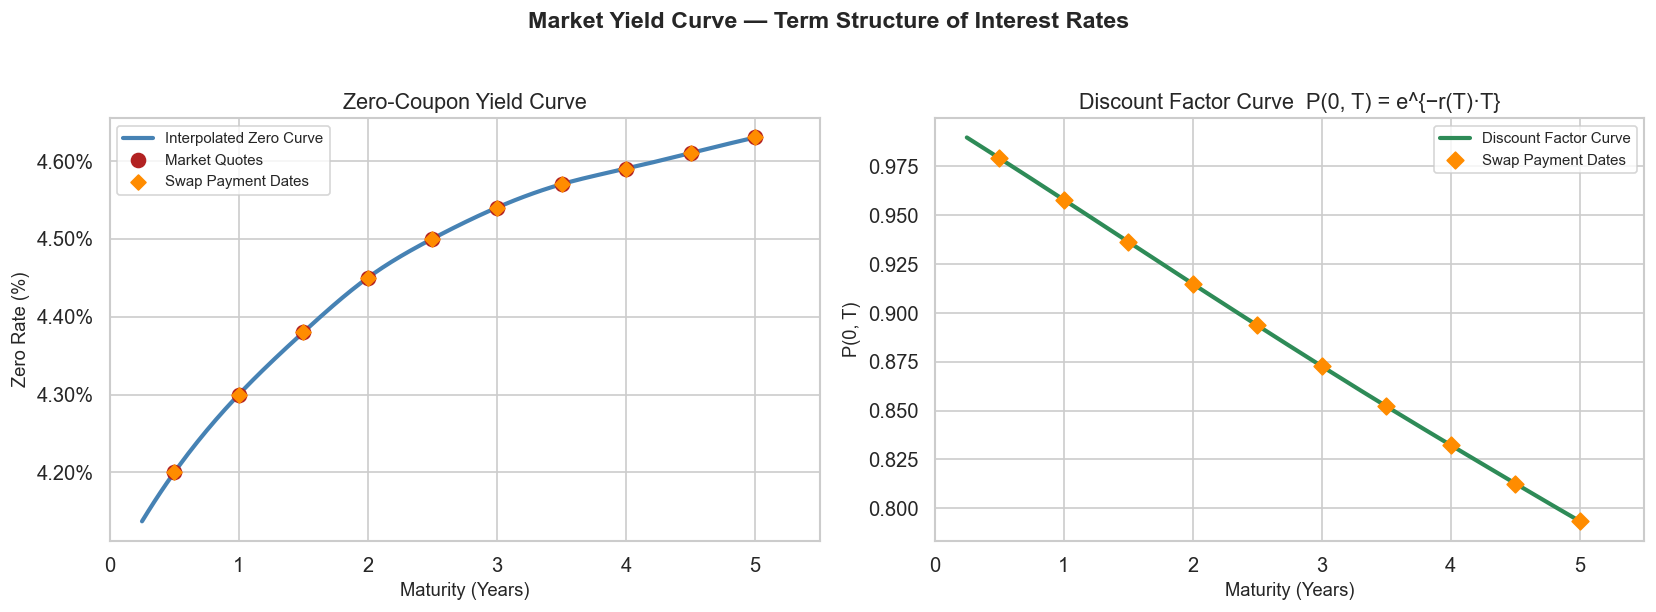


📌 Interpretation:
  • The zero curve is upward sloping (normal yield curve),
    indicating higher rates for longer maturities.
  • Discount factors decline with maturity: $1 received
    further in the future is worth less today.


In [ ]:
T_fine = np.linspace(0.25, 5.0, 200)   # Dense grid for smooth plotting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Zero Rate Curve ──────────────────────────────────────
ax = axes[0]
ax.plot(T_fine, zero_rate(T_fine) * 100, color='steelblue', lw=2.5, label='Interpolated Zero Curve')
ax.scatter(market_maturities, market_zero_rates * 100, color='firebrick',
           zorder=5, s=70, label='Market Quotes')
ax.scatter(PAYMENT_TIMES, zero_rates_at_payments * 100, color='darkorange',
           zorder=5, s=40, marker='D', label='Swap Payment Dates')
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Zero Rate (%)')
ax.set_title('Zero-Coupon Yield Curve')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax.legend(fontsize=9)
ax.set_xlim(0, 5.5)

# ── Right: Discount Factor Curve ──────────────────────────────
ax = axes[1]
ax.plot(T_fine, np.exp(-zero_rate(T_fine) * T_fine), color='seagreen', lw=2.5,
        label='Discount Factor Curve')
ax.scatter(PAYMENT_TIMES, discount_factors_at_pmts, color='darkorange',
           zorder=5, s=50, marker='D', label='Swap Payment Dates')
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('P(0, T)')
ax.set_title('Discount Factor Curve  P(0, T) = e^{−r(T)·T}')
ax.legend(fontsize=9)
ax.set_xlim(0, 5.5)

plt.suptitle('Market Yield Curve — Term Structure of Interest Rates', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("  • The zero curve is upward sloping (normal yield curve),")
print("    indicating higher rates for longer maturities.")
print("  • Discount factors decline with maturity: $1 received")
print("    further in the future is worth less today.")

---
## 5. Constructing Swap Cash Flows

### 5.1 What Are the Cash Flows?

At each payment date $T_i$, two cash flows occur:

**Fixed Leg Cash Flow** (what we pay as fixed-rate payer):
$$
CF^{\text{fixed}}_i = N \cdot K \cdot \alpha_i
$$

**Floating Leg Cash Flow** (what we receive):
$$
CF^{\text{float}}_i = N \cdot f_i \cdot \alpha_i
$$

Where $f_i$ is the **forward rate** for period $[T_{i-1}, T_i]$, derived from the zero curve:
$$
f_i = \frac{1}{\alpha_i} \left( \frac{P(0, T_{i-1})}{P(0, T_i)} - 1 \right)
$$

### 5.2 Net Cash Flow
$$
CF^{\text{net}}_i = CF^{\text{float}}_i - CF^{\text{fixed}}_i
$$

A positive net cash flow means **the fixed-rate payer profits** in that period (floating > fixed).

### 5.3 Forward Rate Intuition

The forward rate $f_i$ is the rate the **market is currently implying** for a loan starting at $T_{i-1}$ and maturing at $T_i$. It is not a prediction — it is an arbitrage-free rate derived from the current zero curve. The floating leg of a swap is valued as if all future floating payments are equal to these forward rates.

In [ ]:
# For period i, the forward rate is computed from consecutive
# discount factors:
#
#   f_i = (1/alpha) * ( P(0, T_{i-1}) / P(0, T_i)  -  1 )
#
# For the first period, T_0 = 0, so P(0, T_0) = P(0, 0) = 1.

def compute_forward_rates(payment_times, alpha):
    """
    Compute simply-compounded forward rates from the zero curve.

    Parameters
    ----------
    payment_times : array of float — payment dates in years
    alpha         : float — day-count fraction per period

    Returns
    -------
    forward_rates : array of float — forward rate for each period
    """
    n = len(payment_times)
    fwd_rates = np.zeros(n)

    for i in range(n):
        # Discount factor at start of period
        # For i=0, the period starts at t=0, so P(0,0) = 1.0
        if i == 0:
            P_start = 1.0
        else:
            P_start = discount_factor(payment_times[i - 1])

        # Discount factor at end of period
        P_end = discount_factor(payment_times[i])

        # Simply-compounded forward rate
        fwd_rates[i] = (1.0 / alpha) * (P_start / P_end - 1.0)

    return fwd_rates

# Compute forward rates at all payment periods
forward_rates = compute_forward_rates(PAYMENT_TIMES, ALPHA)

print("Forward Rates per Payment Period")
print("=" * 50)
for i, (T, fwd) in enumerate(zip(PAYMENT_TIMES, forward_rates)):
    T_start = PAYMENT_TIMES[i-1] if i > 0 else 0.0
    print(f"  Period {i+1:2d}  [{T_start:.1f}y → {T:.1f}y]:  "
          f"Forward Rate = {fwd*100:.4f}%")
print("=" * 50)

Forward Rates per Payment Period
  Period  1  [0.0y → 0.5y]:  Forward Rate = 4.2444%
  Period  2  [0.5y → 1.0y]:  Forward Rate = 4.4488%
  Period  3  [1.0y → 1.5y]:  Forward Rate = 4.5919%
  Period  4  [1.5y → 2.0y]:  Forward Rate = 4.7147%
  Period  5  [2.0y → 2.5y]:  Forward Rate = 4.7557%
  Period  6  [2.5y → 3.0y]:  Forward Rate = 4.7966%
  Period  7  [3.0y → 3.5y]:  Forward Rate = 4.8069%
  Period  8  [3.5y → 4.0y]:  Forward Rate = 4.7864%
  Period  9  [4.0y → 4.5y]:  Forward Rate = 4.8273%
  Period 10  [4.5y → 5.0y]:  Forward Rate = 4.8683%


In [ ]:
# ── Fixed Leg Cash Flows ──────────────────────────────────────
# CF_fixed_i = N * K * alpha   (constant every period)
cf_fixed = NOTIONAL * FIXED_RATE * ALPHA * np.ones(N_PERIODS)

# ── Floating Leg Cash Flows ───────────────────────────────────
# CF_float_i = N * f_i * alpha  (varies with forward rate)
cf_float = NOTIONAL * forward_rates * ALPHA

# ── Net Cash Flows (from fixed-rate payer's perspective) ──────
# Positive = inflow (we receive more from floating than we pay fixed)
# Negative = outflow (we pay more in fixed than we receive floating)
cf_net = cf_float - cf_fixed

# ── Build the Cash Flow Schedule DataFrame ───────────────────
df_cashflows = pd.DataFrame({
    'Period'              : range(1, N_PERIODS + 1),
    'Payment Date (Yrs)'  : PAYMENT_TIMES,
    'Forward Rate (%)'    : forward_rates * 100,
    'Fixed Rate (%)'      : FIXED_RATE * 100,
    'Discount Factor'     : discount_factors_at_pmts,
    'CF Fixed ($)'        : -cf_fixed,    # negative = cash OUTFLOW for fixed payer
    'CF Floating ($)'     : cf_float,     # positive = cash INFLOW
    'Net CF ($)'          : cf_net,       # net: positive = profit for fixed payer
})

print("Complete Swap Cash Flow Schedule")
print("(From the perspective of the FIXED-RATE PAYER)")
print("Positive Net CF = Inflow | Negative Net CF = Outflow")
print("=" * 95)
print(df_cashflows.to_string(index=False))
print("=" * 95)
print(f"\n  Total Undiscounted Fixed  Payments : ${cf_fixed.sum():>15,.2f}")
print(f"  Total Undiscounted Floating Receipts: ${cf_float.sum():>15,.2f}")
print(f"  Total Undiscounted Net Cash Flow    : ${cf_net.sum():>15,.2f}")

Complete Swap Cash Flow Schedule
(From the perspective of the FIXED-RATE PAYER)
Positive Net CF = Inflow | Negative Net CF = Outflow
 Period  Payment Date (Yrs)  Forward Rate (%)  Fixed Rate (%)  Discount Factor    CF Fixed ($)  CF Floating ($)     Net CF ($)
      1            0.500000          4.244410        4.500000         0.979219 -225,000.000000   212,220.516375 -12,779.483625
      2            1.000000          4.448757        4.500000         0.957911 -225,000.000000   222,437.844704  -2,562.155296
      3            1.500000          4.591921        4.500000         0.936412 -225,000.000000   229,596.056277   4,596.056277
      4            2.000000          4.714713        4.500000         0.914846 -225,000.000000   235,735.655607  10,735.655607
      5            2.500000          4.755660        4.500000         0.893597 -225,000.000000   237,783.007466  12,783.007466
      6            3.000000          4.796615        4.500000         0.872668 -225,000.000000   239,830.

---
## 6. Present Value of the Fixed Leg

### 6.1 Concept

The **fixed leg** is like a stream of regular coupon payments — identical in size because both the rate $K$ and the day-count fraction $\alpha$ are constant. It is valued exactly like a fixed-rate bond strip:

$$
PV_{\text{fixed}} = N \cdot K \cdot \alpha \cdot \sum_{i=1}^{n} P(0, T_i)
$$

Since $N \cdot K \cdot \alpha$ is a constant, the fixed-leg PV is simply the **constant cash flow multiplied by the sum of all discount factors** (known as the **annuity factor** or **DV01 equivalent**).

### 6.2 Annuity Factor

The **annuity factor** $A$ is:
$$
A = \alpha \sum_{i=1}^{n} P(0, T_i)
$$

So: $PV_{\text{fixed}} = N \cdot K \cdot A$

The annuity factor is central to everything — it also appears in the par swap rate formula.

In [ ]:
# ── Step 1: Discounted fixed cash flows ───────────────────────
# Each period: PV_i = CF_fixed_i * P(0, T_i)
pv_fixed_per_period = cf_fixed * discount_factors_at_pmts

# ── Step 2: Sum across all periods ────────────────────────────
PV_FIXED = pv_fixed_per_period.sum()

# ── Step 3: Compute Annuity Factor ────────────────────────────
annuity_factor = ALPHA * discount_factors_at_pmts.sum()

# ── Verification: should be equal ─────────────────────────────
PV_FIXED_CHECK = NOTIONAL * FIXED_RATE * annuity_factor

# ── Display detailed breakdown ────────────────────────────────
df_fixed = pd.DataFrame({
    'Period'           : range(1, N_PERIODS + 1),
    'Payment Date (Yrs)': PAYMENT_TIMES,
    'CF Fixed ($)'     : cf_fixed,
    'Discount Factor'  : discount_factors_at_pmts,
    'PV of CF Fixed ($)': pv_fixed_per_period,
    'Cumulative PV ($)': pv_fixed_per_period.cumsum(),
})

print("Fixed Leg — Discounted Cash Flow Analysis")
print("=" * 80)
print(df_fixed.to_string(index=False))
print("=" * 80)
print(f"\n  Fixed Coupon per Period    : ${cf_fixed[0]:>12,.2f}")
print(f"  Sum of Discount Factors    : {discount_factors_at_pmts.sum():>12.6f}")
print(f"  Annuity Factor (A)         : {annuity_factor:>12.6f}")
print(f"")
print(f"  PV of Fixed Leg (summed)   : ${PV_FIXED:>12,.2f}")
print(f"  PV of Fixed Leg (N·K·A)    : ${PV_FIXED_CHECK:>12,.2f}  ← Verification ✅" if abs(PV_FIXED - PV_FIXED_CHECK) < 0.01 else "  ❌ Mismatch!")
print(f"  As % of Notional           : {PV_FIXED/NOTIONAL*100:>11.4f}%")

Fixed Leg — Discounted Cash Flow Analysis
 Period  Payment Date (Yrs)   CF Fixed ($)  Discount Factor  PV of CF Fixed ($)  Cumulative PV ($)
      1            0.500000 225,000.000000         0.979219      220,324.267028     220,324.267028
      2            1.000000 225,000.000000         0.957911      215,530.062765     435,854.329793
      3            1.500000 225,000.000000         0.936412      210,692.642778     646,546.972571
      4            2.000000 225,000.000000         0.914846      205,840.254054     852,387.226626
      5            2.500000 225,000.000000         0.893597      201,059.403099   1,053,446.629725
      6            3.000000 225,000.000000         0.872668      196,350.318319   1,249,796.948044
      7            3.500000 225,000.000000         0.852186      191,741.939375   1,441,538.887419
      8            4.000000 225,000.000000         0.832269      187,260.445060   1,628,799.332479
      9            4.500000 225,000.000000         0.812654      18

---
## 7. Present Value of the Floating Leg

### 7.1 Concept

The **floating leg** is more complex because each future floating cash flow is uncertain — it depends on the reference rate (e.g., SOFR) that will prevail in the future. Under the **risk-neutral pricing** framework, we replace each unknown future rate with its **forward rate** $f_i$ and then discount at the risk-free rate:

$$
PV_{\text{float}} = N \cdot \alpha \cdot \sum_{i=1}^{n} f_i \cdot P(0, T_i)
$$

### 7.2 The Replication Shortcut

A beautiful result from no-arbitrage pricing states that the floating leg is equivalent to:
* **Receiving** the notional $N$ at time 0 (or paying it at time $T_n$)
* **Paying** the notional $N$ at time $T_n$

This gives: $PV_{\text{float}} = N \cdot (1 - P(0, T_n))$

We will verify that both methods give the same answer.

In [ ]:
# ── Method 1: Sum of discounted forward-rate cash flows ────────
pv_float_per_period = cf_float * discount_factors_at_pmts
PV_FLOAT_M1 = pv_float_per_period.sum()

# ── Method 2: Replication (par bond shortcut) ─────────────────
# PV_float = N * (1 - P(0, T_n))
# where T_n is the final maturity
P_final = discount_factor(PAYMENT_TIMES[-1])   # P(0, 5 years)
PV_FLOAT_M2 = NOTIONAL * (1.0 - P_final)

# ── Display detailed breakdown ────────────────────────────────
df_float = pd.DataFrame({
    'Period'              : range(1, N_PERIODS + 1),
    'Payment Date (Yrs)'  : PAYMENT_TIMES,
    'Forward Rate (%)'    : forward_rates * 100,
    'CF Floating ($)'     : cf_float,
    'Discount Factor'     : discount_factors_at_pmts,
    'PV of CF Float ($)'  : pv_float_per_period,
    'Cumulative PV ($)'   : pv_float_per_period.cumsum(),
})

print("Floating Leg — Discounted Cash Flow Analysis")
print("=" * 90)
print(df_float.to_string(index=False))
print("=" * 90)
print(f"\n  Method 1 — Sum of Discounted Fwd CFs  : ${PV_FLOAT_M1:>12,.2f}")
print(f"  Method 2 — Replication N(1 - P(0,T_n)): ${PV_FLOAT_M2:>12,.2f}")
diff = abs(PV_FLOAT_M1 - PV_FLOAT_M2)
print(f"  Difference (rounding/interpolation)   : ${diff:>12.4f}  ",
      "✅ Near-zero — methods agree!" if diff < 500 else "⚠️  Check interpolation")
print(f"\n  PV of Floating Leg (used in valuation) : ${PV_FLOAT_M1:>12,.2f}")
print(f"  As % of Notional                        : {PV_FLOAT_M1/NOTIONAL*100:>11.4f}%")

Floating Leg — Discounted Cash Flow Analysis
 Period  Payment Date (Yrs)  Forward Rate (%)  CF Floating ($)  Discount Factor  PV of CF Float ($)  Cumulative PV ($)
      1            0.500000          4.244410   212,220.516375         0.979219      207,810.354305     207,810.354305
      2            1.000000          4.448757   222,437.844704         0.957911      213,075.745024     420,886.099330
      3            1.500000          4.591921   229,596.056277         0.936412      214,996.443860     635,882.543190
      4            2.000000          4.714713   235,735.655607         0.914846      215,661.721066     851,544.264255
      5            2.500000          4.755660   237,783.007466         0.893597      212,482.264659   1,064,026.528915
      6            3.000000          4.796615   239,830.768837         0.872668      209,292.656906   1,273,319.185821
      7            3.500000          4.806855   240,342.773176         0.852186      204,816.841971   1,478,136.027791
   

---
## 8. Swap Valuation (Net Present Value)

### 8.1 Combining the Two Legs

The **value of the swap** to the fixed-rate payer is the difference between what they receive (floating) and what they pay (fixed), both in present value terms:

$$
V_{\text{swap}} = PV_{\text{float}} - PV_{\text{fixed}}
$$

| Sign | Meaning |
|---|---|
| $V > 0$ | Swap is **in-the-money** for fixed payer — floating receipts > fixed payments |
| $V = 0$ | Swap is **at-the-money** — fair value at inception (par swap) |
| $V < 0$ | Swap is **out-of-the-money** for fixed payer — fixed payments > floating receipts |

For the **floating-rate payer**, the value is simply the negative: $-V_{\text{swap}}$.

In [ ]:
# ── Net swap value: float received minus fixed paid ───────────
V_SWAP = PV_FLOAT_M1 - PV_FIXED

# ── PV of net cash flows directly (should match) ──────────────
pv_net_per_period = cf_net * discount_factors_at_pmts
V_SWAP_CHECK      = pv_net_per_period.sum()

# ── Build the final valuation summary table ───────────────────
df_valuation = pd.DataFrame({
    'Period'             : range(1, N_PERIODS + 1),
    'Date (Yrs)'         : PAYMENT_TIMES,
    'PV Fixed ($)'       : -pv_fixed_per_period,   # outflow → shown as negative
    'PV Float ($)'       : pv_float_per_period,
    'PV Net ($)'         : pv_net_per_period,
    'Cumulative NPV ($)' : pv_net_per_period.cumsum(),
})

print("Swap Valuation — Period-by-Period NPV Summary")
print("(Fixed-Rate Payer Perspective: Fixed = Outflow, Floating = Inflow)")
print("=" * 85)
print(df_valuation.to_string(index=False))
print("=" * 85)

print("\n" + "=" * 55)
print("       SWAP VALUATION RESULT")
print("=" * 55)
print(f"  PV of Fixed Leg     : ${PV_FIXED:>14,.2f}  (outflow)")
print(f"  PV of Floating Leg  : ${PV_FLOAT_M1:>14,.2f}  (inflow)")
print("  " + "-" * 45)
print(f"  Swap NPV (V_swap)   : ${V_SWAP:>14,.2f}")
print(f"  Verification Check  : ${V_SWAP_CHECK:>14,.2f}  ✅" if abs(V_SWAP - V_SWAP_CHECK) < 1 else "  ❌ Mismatch")
print("=" * 55)
if V_SWAP > 0:
    print(f"  📈 The swap is IN-THE-MONEY for the fixed-rate payer.")
    print(f"     Floating receipts exceed fixed payments by ${V_SWAP:,.2f}.")
elif V_SWAP < 0:
    print(f"  📉 The swap is OUT-OF-THE-MONEY for the fixed-rate payer.")
    print(f"     Fixed payments exceed floating receipts by ${-V_SWAP:,.2f}.")
else:
    print("  ⚖️  The swap is AT-THE-MONEY (par swap).")
print("=" * 55)

Swap Valuation — Period-by-Period NPV Summary
(Fixed-Rate Payer Perspective: Fixed = Outflow, Floating = Inflow)
 Period  Date (Yrs)    PV Fixed ($)   PV Float ($)     PV Net ($)  Cumulative NPV ($)
      1    0.500000 -220,324.267028 207,810.354305 -12,513.912723      -12,513.912723
      2    1.000000 -215,530.062765 213,075.745024  -2,454.317741      -14,968.230464
      3    1.500000 -210,692.642778 214,996.443860   4,303.801082      -10,664.429382
      4    2.000000 -205,840.254054 215,661.721066   9,821.467011         -842.962370
      5    2.500000 -201,059.403099 212,482.264659  11,422.861560       10,579.899190
      6    3.000000 -196,350.318319 209,292.656906  12,942.338587       23,522.237777
      7    3.500000 -191,741.939375 204,816.841971  13,074.902596       36,597.140373
      8    4.000000 -187,260.445060 199,177.525089  11,917.080029       48,514.220402
      9    4.500000 -182,847.121526 196,147.712610  13,300.591083       61,814.811485
     10    5.000000 -178,50

---
## 9. Par (Fair) Swap Rate Calculation

### 9.1 What is the Par Swap Rate?

The **par swap rate** $K^*$ is the fixed rate that makes the swap's NPV exactly **zero** at inception. It is the market's "fair" fixed rate for the given maturity and reference rate.

Setting $V_{\text{swap}} = 0$:
$$
PV_{\text{float}} = PV_{\text{fixed}}
$$
$$
N \cdot \sum_{i=1}^{n} \alpha_i \cdot f_i \cdot P(0, T_i) = N \cdot K^* \cdot \sum_{i=1}^{n} \alpha_i \cdot P(0, T_i)
$$

Solving directly:
$$
K^* = \frac{\sum_{i=1}^{n} \alpha_i \cdot f_i \cdot P(0, T_i)}{\sum_{i=1}^{n} \alpha_i \cdot P(0, T_i)} = \frac{PV_{\text{float}} / N}{A}
$$

### 9.2 Interpretation

* If $K > K^*$: The fixed-rate payer is paying **too much** fixed → swap is out-of-the-money for them
* If $K < K^*$: The fixed-rate payer is paying **too little** fixed → swap is in-the-money for them
* If $K = K^*$: At-the-money — zero NPV at inception

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 9.1  —  Par Swap Rate
# ─────────────────────────────────────────────────────────────

# ── Direct Formula ────────────────────────────────────────────
# K* = (sum of discounted floating CFs / N) / Annuity Factor
numerator   = np.sum(ALPHA * forward_rates * discount_factors_at_pmts)
denominator = annuity_factor
K_PAR = numerator / denominator

# ── Alternative: K* = (1 - P(0,T_n)) / A  [replication shortcut]
K_PAR_ALT = (1.0 - P_final) / annuity_factor

print("=" * 55)
print("       PAR SWAP RATE CALCULATION")
print("=" * 55)
print(f"  Floating PV Numerator      : {numerator:.8f}")
print(f"  Annuity Factor (denominator): {annuity_factor:.8f}")
print("  " + "-" * 45)
print(f"  Par Swap Rate K* (formula) : {K_PAR*100:.6f}%")
print(f"  Par Swap Rate K* (shortcut): {K_PAR_ALT*100:.6f}%")
print("=" * 55)
print(f"\n  Contracted Fixed Rate K    : {FIXED_RATE*100:.4f}%")
print(f"  Par Rate K*                : {K_PAR*100:.4f}%")
print(f"  Spread (K - K*)            : {(FIXED_RATE - K_PAR)*100*100:.2f} basis points")
print("")
if FIXED_RATE > K_PAR:
    print("  📉 We locked in a fixed rate ABOVE market par.")
    print("     → Swap is out-of-the-money for fixed-rate payer.")
elif FIXED_RATE < K_PAR:
    print("  📈 We locked in a fixed rate BELOW market par.")
    print("     → Swap is in-the-money for fixed-rate payer.")
else:
    print("  ⚖️  Fixed rate equals par rate — at-the-money.")
print("=" * 55)

       PAR SWAP RATE CALCULATION
  Floating PV Numerator      : 0.20665730
  Annuity Factor (denominator): 4.42255236
  ---------------------------------------------
  Par Swap Rate K* (formula) : 4.672806%
  Par Swap Rate K* (shortcut): 4.672806%

  Contracted Fixed Rate K    : 4.5000%
  Par Rate K*                : 4.6728%
  Spread (K - K*)            : -17.28 basis points

  📈 We locked in a fixed rate BELOW market par.
     → Swap is in-the-money for fixed-rate payer.


---
## 10. Interest Rate Sensitivity Analysis

### 10.1 Why Sensitivity Analysis?

After inception, the **swap's mark-to-market value changes as interest rates move**. A fixed-rate payer is effectively **long duration** — the swap gains value when rates rise (floating received increases, fixed paid stays constant) and loses value when rates fall.

We analyse three types of sensitivity:

1. **Parallel Shifts** — the entire yield curve moves up or down by the same amount
2. **DV01** — the dollar change for a 1 basis point shift
3. **Non-Parallel Scenarios** — steepening and flattening of the yield curve

### 10.2 DV01 (Dollar Value of a Basis Point)

$$
\text{DV01} \approx \frac{V(r + 0.0001) - V(r - 0.0001)}{2}
$$

We use the **central difference** approximation for numerical accuracy.

### 10.3 Duration and Modified Duration

The **modified duration** of the swap (fixed-rate payer) is approximately:
$$
D_{\text{mod}} = \frac{\text{DV01} \times 10000}{N}
$$

It represents the **percentage change** in swap value per 1% change in rates.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 10.1  —  Utility: Revalue Swap Under a Shifted Curve
# ─────────────────────────────────────────────────────────────
#
# We create a general function that re-prices the swap given
# a shifted zero curve. This function is the engine for all
# sensitivity calculations.

def value_swap_shifted(shift_bps, fixed_rate=FIXED_RATE,
                       notional=NOTIONAL, payment_times=PAYMENT_TIMES,
                       alpha=ALPHA, base_zero_rates=market_zero_rates,
                       base_maturities=market_maturities):
    """
    Re-value the swap after applying a PARALLEL shift to the zero curve.

    Parameters
    ----------
    shift_bps   : float — parallel shift in basis points (e.g., 50 = +50bp)
    fixed_rate  : float — contractual fixed rate
    ...

    Returns
    -------
    dict with keys: pv_fixed, pv_float, v_swap, par_rate
    """
    shift = shift_bps / 10_000.0    # Convert basis points to decimal

    # Shifted zero rates
    shifted_rates = base_zero_rates + shift

    # Re-fit spline on shifted curve
    shifted_spline = CubicSpline(base_maturities, shifted_rates)

    # Helper functions using the shifted curve
    def zr_shifted(T):
        return float(shifted_spline(T)) if np.isscalar(T) else shifted_spline(T)

    def df_shifted(T):
        return np.exp(-zr_shifted(T) * T)

    # Recompute discount factors and forward rates
    dfs  = df_shifted(payment_times)
    fwds = np.array([
        (1/alpha) * ((1.0 if i == 0 else df_shifted(payment_times[i-1])) / dfs[i] - 1)
        for i in range(len(payment_times))
    ])

    # PV calculations
    cf_f  = notional * fixed_rate * alpha
    cf_fl = notional * fwds * alpha
    pv_f  = (cf_f * dfs).sum()
    pv_fl = (cf_fl * dfs).sum()
    v     = pv_fl - pv_f

    # Par rate
    A_factor = alpha * dfs.sum()
    k_par = (notional * (1 - df_shifted(payment_times[-1])) / notional) / A_factor

    return {'pv_fixed': pv_f, 'pv_float': pv_fl, 'v_swap': v, 'par_rate': k_par}

print("✅  Sensitivity function defined.")
print(f"    Base case swap value: ${V_SWAP:,.2f}")

# Quick sanity check: shift of 0 bps should reproduce base case
base_check = value_swap_shifted(0)
print(f"    0bp shift check    : ${base_check['v_swap']:,.2f}  ← Should match above")

✅  Sensitivity function defined.
    Base case swap value: $76,424.48
    0bp shift check    : $76,424.48  ← Should match above


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 10.2  —  DV01 Calculation
# ─────────────────────────────────────────────────────────────

# Central difference approximation: +1bp and -1bp
v_up_1bp   = value_swap_shifted(+1)['v_swap']    # Rate curve up by 1bp
v_down_1bp = value_swap_shifted(-1)['v_swap']    # Rate curve down by 1bp

DV01 = (v_up_1bp - v_down_1bp) / 2.0

# Modified Duration (approximate) = DV01 * 10000 / Notional
# Represents % change per 1% move in rates
mod_duration = DV01 * 10_000 / NOTIONAL

print("=" * 55)
print("       DV01 — RATE SENSITIVITY")
print("=" * 55)
print(f"  Swap Value at  +1bp : ${v_up_1bp:>12,.2f}")
print(f"  Swap Value at   0bp : ${V_SWAP:>12,.2f}  (base)")
print(f"  Swap Value at  -1bp : ${v_down_1bp:>12,.2f}")
print("  " + "-" * 45)
print(f"  DV01                : ${DV01:>12,.2f} per 1bp")
print(f"  Modified Duration   : {mod_duration:>12.4f} years")
print("=" * 55)
print(f"\n  📌 Interpretation:")
print(f"     For every 1 basis point RISE in rates,")
print(f"     the swap's value changes by ${DV01:,.2f}.")
print(f"")
print(f"     For a 100bp (1%) rate shock:")
print(f"     Estimated change = ${DV01 * 100:,.2f}")

       DV01 — RATE SENSITIVITY
  Swap Value at  +1bp : $   80,918.17
  Swap Value at   0bp : $   76,424.48  (base)
  Swap Value at  -1bp : $   71,928.63
  ---------------------------------------------
  DV01                : $    4,494.77 per 1bp
  Modified Duration   :       4.4948 years

  📌 Interpretation:
     For every 1 basis point RISE in rates,
     the swap's value changes by $4,494.77.

     For a 100bp (1%) rate shock:
     Estimated change = $449,477.09


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 10.3  —  Parallel Shift Scenario Analysis
# ─────────────────────────────────────────────────────────────
# We evaluate the swap's value across a wide range of
# parallel yield curve shifts: from -300bp to +300bp

shift_range_bps = np.arange(-300, 325, 25)    # -300bp to +300bp in 25bp steps

results = []
for shift in shift_range_bps:
    res = value_swap_shifted(shift)
    results.append({
        'Shift (bps)'       : shift,
        'Yield Shift (%)'   : shift / 100,
        'PV Fixed ($)'      : res['pv_fixed'],
        'PV Float ($)'      : res['pv_float'],
        'Swap NPV ($)'      : res['v_swap'],
        'Par Rate (%)'      : res['par_rate'] * 100,
        'Change from Base ($)': res['v_swap'] - V_SWAP,
    })

df_scenarios = pd.DataFrame(results)

print("Parallel Shift Scenario Analysis")
print("(Fixed-Rate Payer Perspective)")
print("=" * 90)
# Show selected rows for readability (every 50bps)
mask = df_scenarios['Shift (bps)'] % 50 == 0
print(df_scenarios[mask][[
    'Shift (bps)', 'PV Fixed ($)', 'PV Float ($)',
    'Swap NPV ($)', 'Par Rate (%)', 'Change from Base ($)'
]].to_string(index=False))
print("=" * 90)

Parallel Shift Scenario Analysis
(Fixed-Rate Payer Perspective)
 Shift (bps)     PV Fixed ($)     PV Float ($)      Swap NPV ($)  Par Rate (%)  Change from Base ($)
        -300 2,157,037.748871   782,672.901461 -1,374,364.847410      1.632808     -1,450,789.331885
        -250 2,128,007.474341 1,010,249.518388 -1,117,757.955953      2.136328     -1,194,182.440428
        -200 2,099,476.020047 1,232,207.248622   -867,268.771424      2.641103       -943,693.255900
        -150 2,071,433.745937 1,448,684.822971   -622,748.922966      3.147135       -699,173.407441
        -100 2,043,871.210749 1,659,817.546965   -384,053.663784      3.654427       -460,478.148259
         -50 2,016,779.167736 1,865,737.385430   -151,041.782306      4.162983       -227,466.266781
           0 1,990,148.560494 2,066,573.044969     76,424.484475      4.672806              0.000000
          50 1,963,970.518876 2,262,450.054405    298,479.535529      5.183899        222,055.051054
         100 1,938,236.3550

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 10.4  —  Key Scenario Summary
# ─────────────────────────────────────────────────────────────
# Highlight practical stress test scenarios

stress_scenarios = [-200, -100, -50, -25, 0, 25, 50, 100, 200]

print("\nStress Test Scenarios — Key Rate Shifts")
print("=" * 75)
print(f"  {'Scenario':<20} {'Shift':>8} {'Swap NPV':>14} {'Change':>14} {'Direction':>12}")
print("  " + "-" * 68)
for shift in stress_scenarios:
    res   = value_swap_shifted(shift)
    v     = res['v_swap']
    chg   = v - V_SWAP
    desc  = f"+{shift}bp" if shift >= 0 else f"{shift}bp"
    arrow = "📈 +" if chg > 0 else ("📉 -" if chg < 0 else "─")
    scenario_name = {
        -200: "Severe Rate Drop",
        -100: "Rate Drop 100bp",
        -50 : "Mild Rate Drop",
        -25 : "Small Rate Drop",
        0   : "Base Case",
        25  : "Small Rate Rise",
        50  : "Mild Rate Rise",
        100 : "Rate Rise 100bp",
        200 : "Severe Rate Rise",
    }.get(shift, f"{desc}")
    print(f"  {scenario_name:<20} {desc:>8} ${v:>12,.2f} {arrow}${abs(chg):>11,.2f}")
print("=" * 75)
print("\n  📌 Key Insight:")
print("     As a fixed-rate payer, we GAIN when rates RISE")
print("     (floating receipts increase while fixed payments stay constant).")
print("     We LOSE when rates FALL.")
print("     This is equivalent to being SHORT a fixed-rate bond.")


Stress Test Scenarios — Key Rate Shifts
  Scenario                Shift       Swap NPV         Change    Direction
  --------------------------------------------------------------------
  Severe Rate Drop       -200bp $ -867,268.77 📉 -$ 943,693.26
  Rate Drop 100bp        -100bp $ -384,053.66 📉 -$ 460,478.15
  Mild Rate Drop          -50bp $ -151,041.78 📉 -$ 227,466.27
  Small Rate Drop         -25bp $  -36,623.92 📉 -$ 113,048.41
  Base Case                +0bp $   76,424.48 ─$       0.00
  Small Rate Rise         +25bp $  188,120.14 📈 +$ 111,695.66
  Mild Rate Rise          +50bp $  298,479.54 📈 +$ 222,055.05
  Rate Rise 100bp        +100bp $  515,254.49 📈 +$ 438,830.00
  Severe Rate Rise       +200bp $  933,472.64 📈 +$ 857,048.16

  📌 Key Insight:
     As a fixed-rate payer, we GAIN when rates RISE
     (floating receipts increase while fixed payments stay constant).
     We LOSE when rates FALL.
     This is equivalent to being SHORT a fixed-rate bond.


In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 10.5  —  Non-Parallel Shifts: Steepening & Flattening
# ─────────────────────────────────────────────────────────────
#
# Real yield curves don't just shift — they twist.
# We model three non-parallel scenarios:
#
#   1. Steepener: Short rates fall, long rates rise
#      Shift(T) = -100bp + (T/5)*200bp  →  -100bp at 0yr, +100bp at 5yr
#
#   2. Flattener: Short rates rise, long rates fall
#      Shift(T) = +100bp - (T/5)*200bp  →  +100bp at 0yr, -100bp at 5yr
#
#   3. Bear Flattener: Long rates rise, short rates stable
#      Shift(T) = (T/5)*100bp

def value_swap_custom_shift(shift_fn):
    """
    Re-value swap with a custom, maturity-dependent shift.
    shift_fn: callable T → shift in bp (e.g., lambda T: 50 for flat +50bp)
    """
    shifted_rates = market_zero_rates + shift_fn(market_maturities) / 10_000
    spl = CubicSpline(market_maturities, shifted_rates)

    def df_s(T): return np.exp(-float(spl(T)) * T) if np.isscalar(T) else np.exp(-spl(T) * T)

    dfs  = df_s(PAYMENT_TIMES)
    fwds = np.array([
        (1/ALPHA) * ((1.0 if i == 0 else df_s(PAYMENT_TIMES[i-1])) / dfs[i] - 1)
        for i in range(N_PERIODS)
    ])
    pv_f  = (NOTIONAL * FIXED_RATE * ALPHA * dfs).sum()
    pv_fl = (NOTIONAL * fwds * ALPHA * dfs).sum()
    return pv_fl - pv_f

# Define scenario functions
scenarios_np = {
    'Base Case'       : lambda T: T * 0,
    'Steepener'       : lambda T: -100 + (T / 5) * 200,
    'Flattener'       : lambda T: +100 - (T / 5) * 200,
    'Bull Steepener'  : lambda T: -50 - (T / 5) * 50,
    'Bear Steepener'  : lambda T: +50 + (T / 5) * 50,
    '+100bp Parallel' : lambda T: T * 0 + 100,
    '-100bp Parallel' : lambda T: T * 0 - 100,
}

print("Non-Parallel Yield Curve Scenarios")
print("=" * 60)
print(f"  {'Scenario':<22} {'Swap NPV ($)':>14} {'Change ($)':>14}")
print("  " + "-" * 52)
np_results = {}
for name, fn in scenarios_np.items():
    val = value_swap_custom_shift(fn)
    chg = val - V_SWAP
    np_results[name] = {'npv': val, 'change': chg}
    print(f"  {name:<22} ${val:>12,.2f}  {'+' if chg>=0 else ''}{chg:>12,.2f}")
print("=" * 60)

Non-Parallel Yield Curve Scenarios
  Scenario                 Swap NPV ($)     Change ($)
  ----------------------------------------------------
  Base Case              $   76,424.48  +        0.00
  Steepener              $  482,521.27  +  406,096.78
  Flattener              $ -350,368.02   -426,792.50
  Bull Steepener         $ -375,568.39   -451,992.88
  Bear Steepener         $  507,133.08  +  430,708.59
  +100bp Parallel        $  515,254.49  +  438,830.00
  -100bp Parallel        $ -384,053.66   -460,478.15


---
## 11. Visualisations & Summary Dashboard

We now produce a comprehensive set of charts that visually summarise every aspect of the swap analysis.

Charts produced:
1. **Cash Flow Bar Chart** — Fixed vs Floating per period
2. **Discounted Cash Flows** — PV of each leg per period
3. **Swap NPV vs Yield Shift** — Full sensitivity curve
4. **PV Breakdown** — Fixed vs Floating leg as rates change
5. **Forward Rate Term Structure** — Forward rates vs zero rates
6. **Scenario Bar Chart** — NPV under all stress scenarios

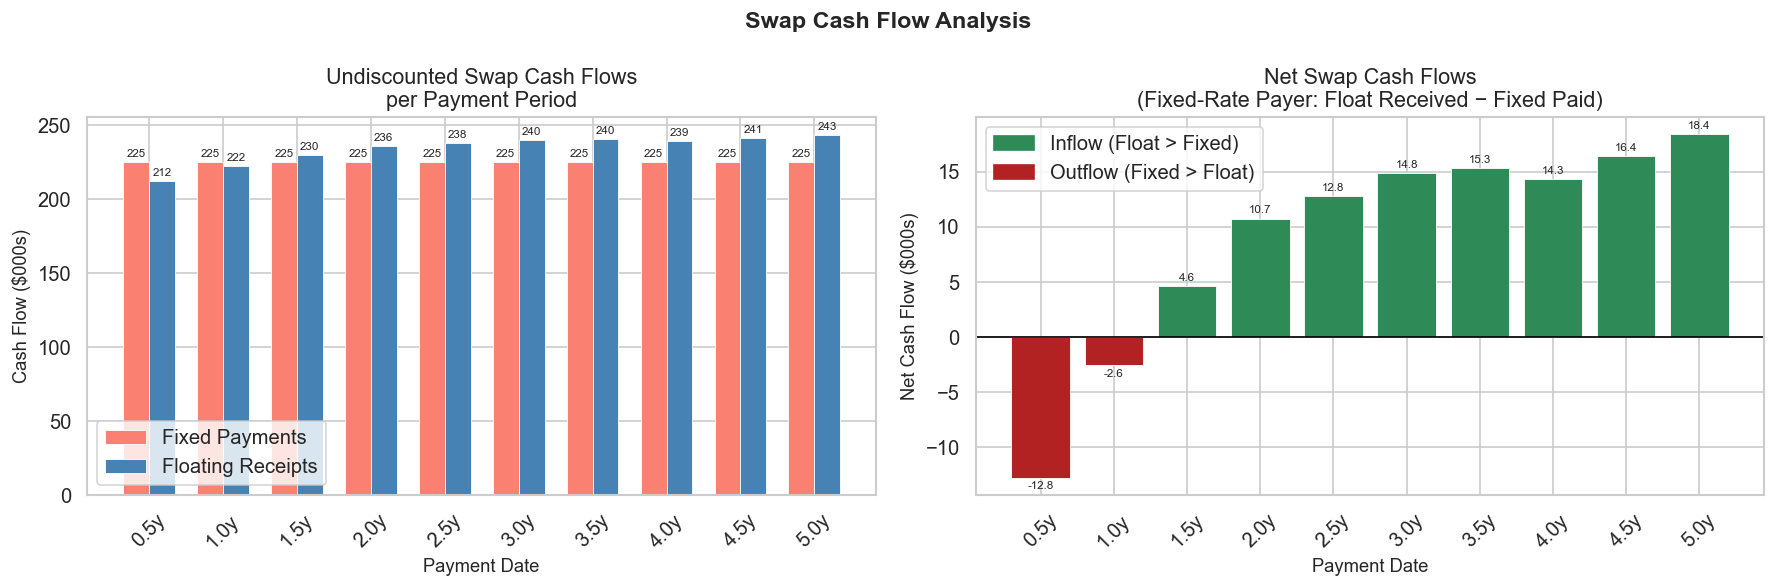

In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 11.1  —  Cash Flow Chart (Undiscounted)
# ─────────────────────────────────────────────────────────────

x = np.arange(N_PERIODS)
bar_width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Raw cash flows ──────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - bar_width/2, cf_fixed / 1000, bar_width, label='Fixed Payments',
            color='salmon', edgecolor='white', linewidth=0.5)
b2 = ax.bar(x + bar_width/2, cf_float / 1000, bar_width, label='Floating Receipts',
            color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'{t:.1f}y' for t in PAYMENT_TIMES], rotation=45)
ax.set_xlabel('Payment Date')
ax.set_ylabel('Cash Flow ($000s)')
ax.set_title('Undiscounted Swap Cash Flows\nper Payment Period')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
ax.bar_label(b1, fmt='%.0f', padding=2, fontsize=7)
ax.bar_label(b2, fmt='%.0f', padding=2, fontsize=7)

# ── Right: Net cash flows ─────────────────────────────────────
ax = axes[1]
colors_net = ['seagreen' if v >= 0 else 'firebrick' for v in cf_net]
bars = ax.bar(x, cf_net / 1000, color=colors_net, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'{t:.1f}y' for t in PAYMENT_TIMES], rotation=45)
ax.set_xlabel('Payment Date')
ax.set_ylabel('Net Cash Flow ($000s)')
ax.set_title('Net Swap Cash Flows\n(Fixed-Rate Payer: Float Received − Fixed Paid)')
ax.axhline(0, color='black', linewidth=1.0)
ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=7)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='seagreen', label='Inflow (Float > Fixed)'),
                   Patch(color='firebrick', label='Outflow (Fixed > Float)')])

plt.suptitle('Swap Cash Flow Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

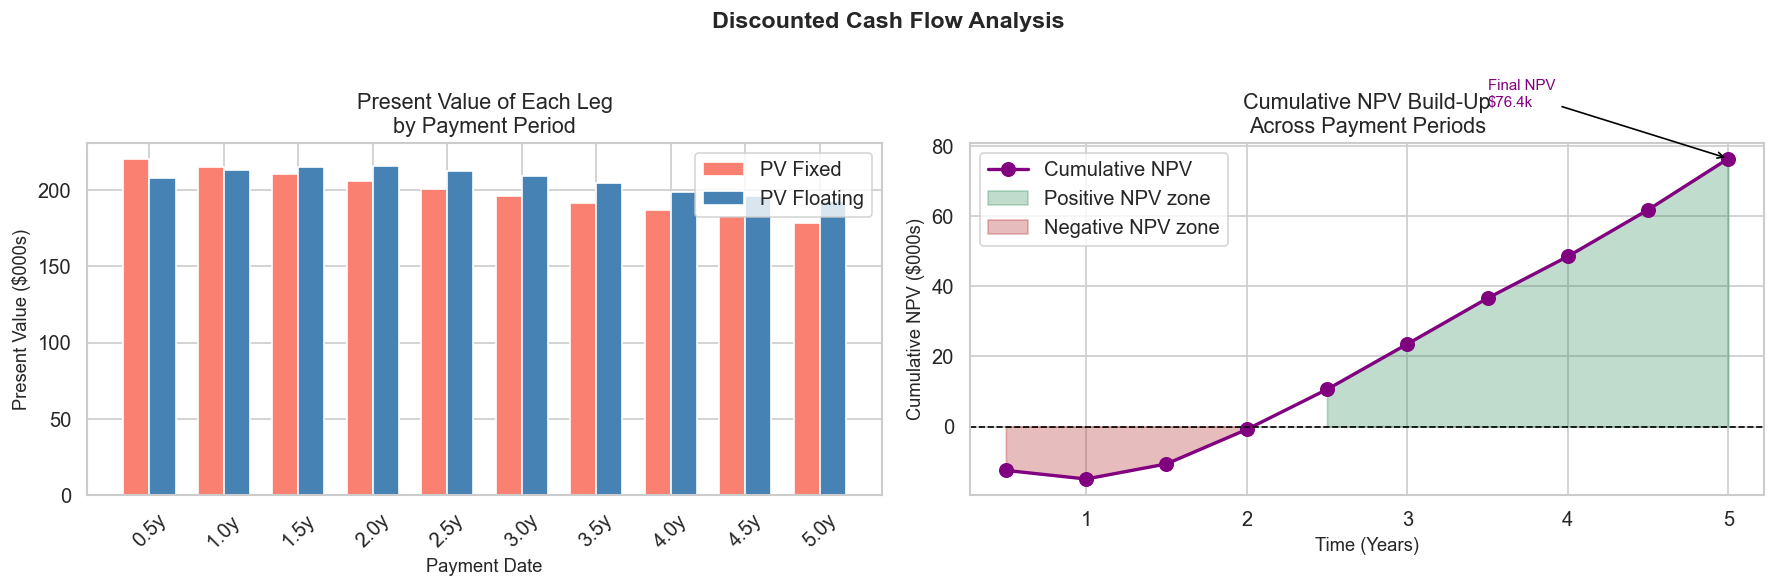

In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 11.2  —  Discounted Cash Flows & Cumulative NPV
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: PV of each leg per period ───────────────────────────
ax = axes[0]
ax.bar(x - bar_width/2, pv_fixed_per_period / 1000, bar_width,
       label='PV Fixed', color='salmon', edgecolor='white')
ax.bar(x + bar_width/2, pv_float_per_period / 1000, bar_width,
       label='PV Floating', color='steelblue', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'{t:.1f}y' for t in PAYMENT_TIMES], rotation=45)
ax.set_xlabel('Payment Date')
ax.set_ylabel('Present Value ($000s)')
ax.set_title('Present Value of Each Leg\nby Payment Period')
ax.legend()

# ── Right: Cumulative NPV build-up ────────────────────────────
ax = axes[1]
cumulative_npv = pv_net_per_period.cumsum() / 1000
ax.plot(PAYMENT_TIMES, cumulative_npv, 'o-', color='purple', lw=2, markersize=8, label='Cumulative NPV')
ax.fill_between(PAYMENT_TIMES, 0, cumulative_npv,
                where=(cumulative_npv >= 0), alpha=0.3, color='seagreen', label='Positive NPV zone')
ax.fill_between(PAYMENT_TIMES, 0, cumulative_npv,
                where=(cumulative_npv < 0),  alpha=0.3, color='firebrick', label='Negative NPV zone')
ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
ax.set_xlabel('Time (Years)')
ax.set_ylabel('Cumulative NPV ($000s)')
ax.set_title('Cumulative NPV Build-Up\nAcross Payment Periods')
ax.legend()
# Annotate final NPV
ax.annotate(f'Final NPV\n${V_SWAP/1000:,.1f}k',
            xy=(PAYMENT_TIMES[-1], cumulative_npv[-1]),
            xytext=(PAYMENT_TIMES[-1] - 1.5, cumulative_npv[-1] + 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='purple')

plt.suptitle('Discounted Cash Flow Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

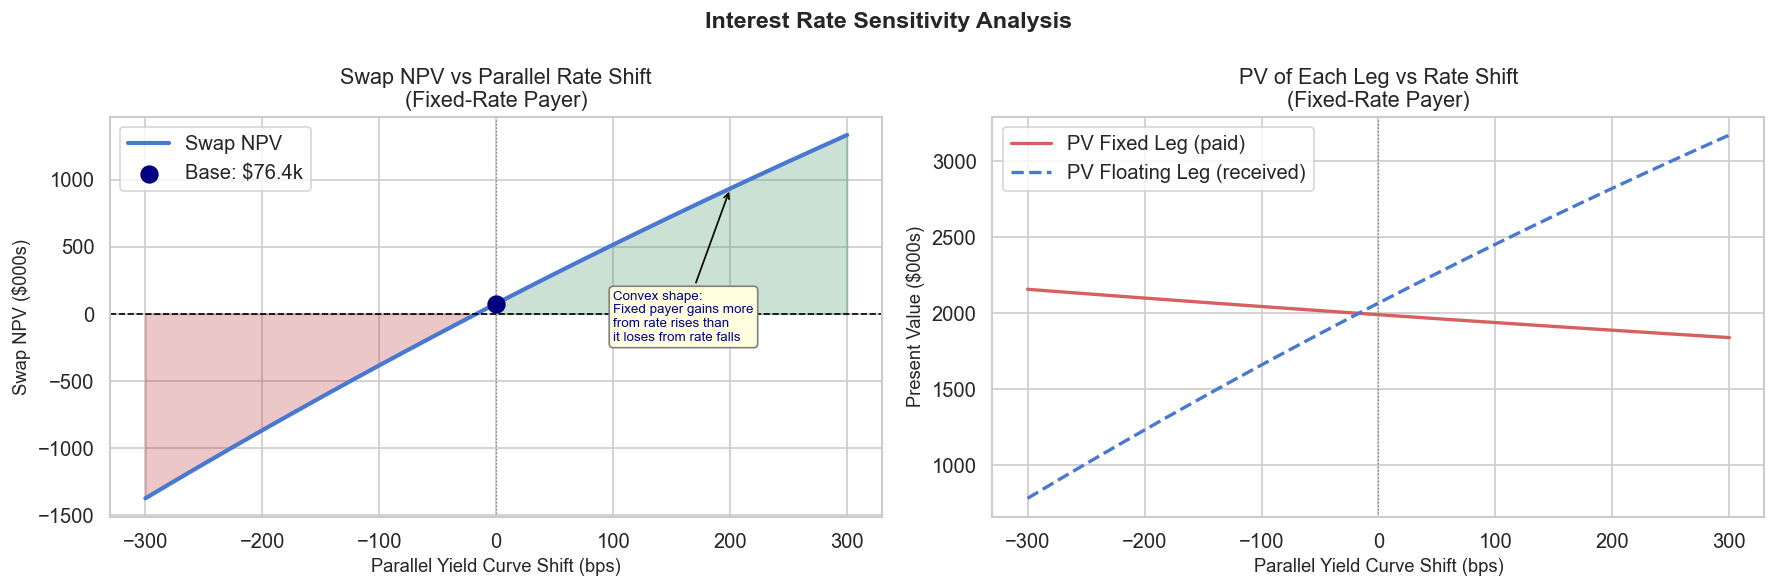

In [21]:
# ─────────────────────────────────────────────────────────────
# CELL 11.3  —  Swap NPV vs Parallel Rate Shifts
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

npv_values   = df_scenarios['Swap NPV ($)'].values / 1000
shift_values = df_scenarios['Shift (bps)'].values
pv_f_values  = df_scenarios['PV Fixed ($)'].values / 1000
pv_fl_values = df_scenarios['PV Float ($)'].values / 1000

# ── Left: NPV vs shift ────────────────────────────────────────
ax = axes[0]
ax.plot(shift_values, npv_values, 'b-', lw=2.5, label='Swap NPV')
ax.fill_between(shift_values, 0, npv_values,
                where=(np.array(npv_values) >= 0), alpha=0.25, color='seagreen')
ax.fill_between(shift_values, 0, npv_values,
                where=(np.array(npv_values) <  0), alpha=0.25, color='firebrick')
ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
ax.axvline(0, color='grey',  linewidth=0.8, linestyle=':')
ax.scatter([0], [V_SWAP / 1000], color='navy', s=100, zorder=5, label=f'Base: ${V_SWAP/1000:,.1f}k')
ax.set_xlabel('Parallel Yield Curve Shift (bps)')
ax.set_ylabel('Swap NPV ($000s)')
ax.set_title('Swap NPV vs Parallel Rate Shift\n(Fixed-Rate Payer)')
ax.legend()

# ── Right: Fixed vs Floating PV as rates change ───────────────
ax = axes[1]
ax.plot(shift_values, pv_f_values,  'r-',  lw=2, label='PV Fixed Leg (paid)')
ax.plot(shift_values, pv_fl_values, 'b--', lw=2, label='PV Floating Leg (received)')
ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Parallel Yield Curve Shift (bps)')
ax.set_ylabel('Present Value ($000s)')
ax.set_title('PV of Each Leg vs Rate Shift\n(Fixed-Rate Payer)')
ax.legend()

# ── Annotation explaining convexity ──────────────────────────
ax = axes[0]
ax.annotate('Convex shape:\nFixed payer gains more\nfrom rate rises than\nit loses from rate falls',
            xy=(200, npv_values[np.searchsorted(shift_values, 200)]),
            xytext=(100, -200),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=8, color='darkblue',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='grey'))

plt.suptitle('Interest Rate Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

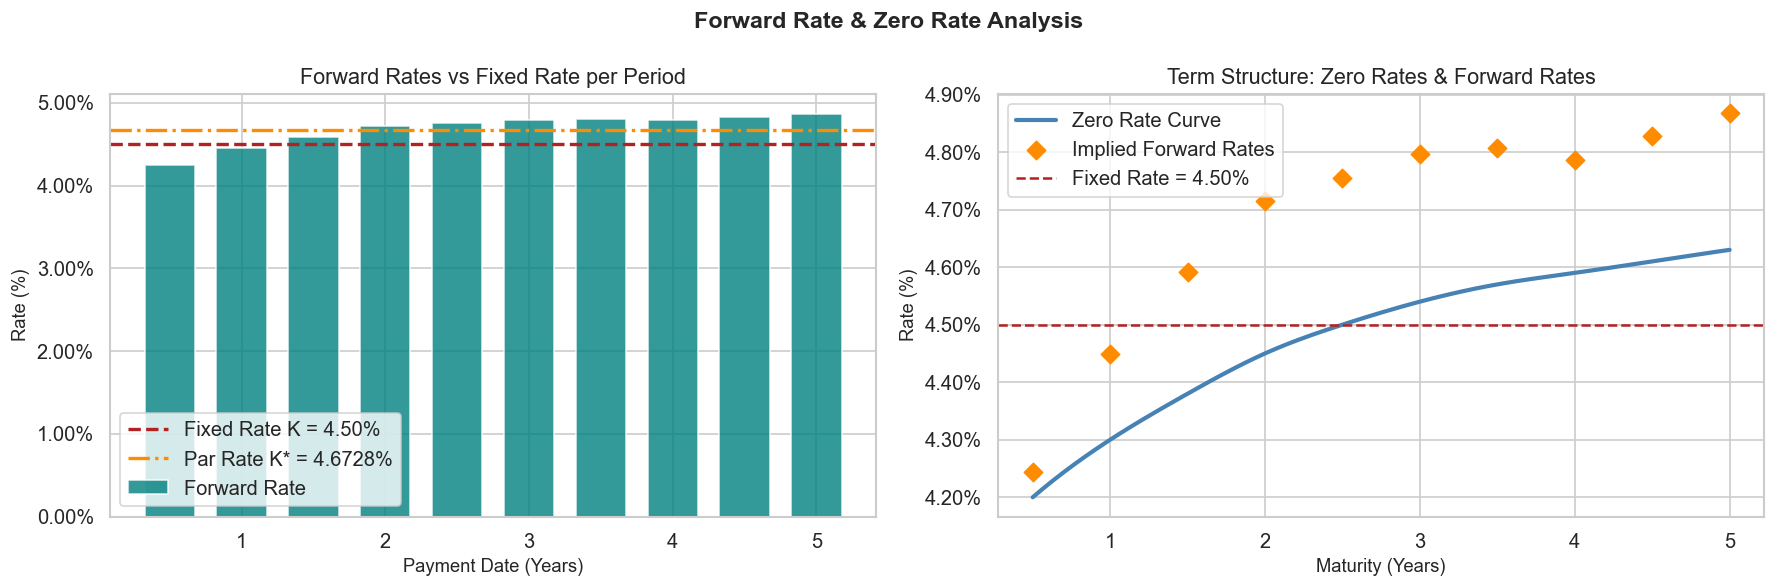

In [22]:
# ─────────────────────────────────────────────────────────────
# CELL 11.4  —  Forward Rates vs Zero Rates
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Forward rates at each payment period ────────────────
ax = axes[0]
ax.bar(PAYMENT_TIMES, forward_rates * 100, width=0.35, color='teal',
       alpha=0.8, edgecolor='white', label='Forward Rate')
ax.axhline(FIXED_RATE * 100, color='firebrick', lw=2, linestyle='--',
           label=f'Fixed Rate K = {FIXED_RATE*100:.2f}%')
ax.axhline(K_PAR * 100, color='darkorange', lw=2, linestyle='-.',
           label=f'Par Rate K* = {K_PAR*100:.4f}%')
ax.set_xlabel('Payment Date (Years)')
ax.set_ylabel('Rate (%)')
ax.set_title('Forward Rates vs Fixed Rate per Period')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))

# ── Right: Zero rates vs forward rates on smooth curves ───────
ax = axes[1]
T_plot = np.linspace(0.5, 5.0, 200)
ax.plot(T_plot, zero_rate(T_plot) * 100, 'steelblue', lw=2.5, label='Zero Rate Curve')
ax.scatter(PAYMENT_TIMES, forward_rates * 100, s=60, color='darkorange',
           zorder=5, label='Implied Forward Rates', marker='D')
ax.axhline(FIXED_RATE * 100, color='firebrick', lw=1.5, linestyle='--',
           label=f'Fixed Rate = {FIXED_RATE*100:.2f}%')
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Rate (%)')
ax.set_title('Term Structure: Zero Rates & Forward Rates')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))

plt.suptitle('Forward Rate & Zero Rate Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

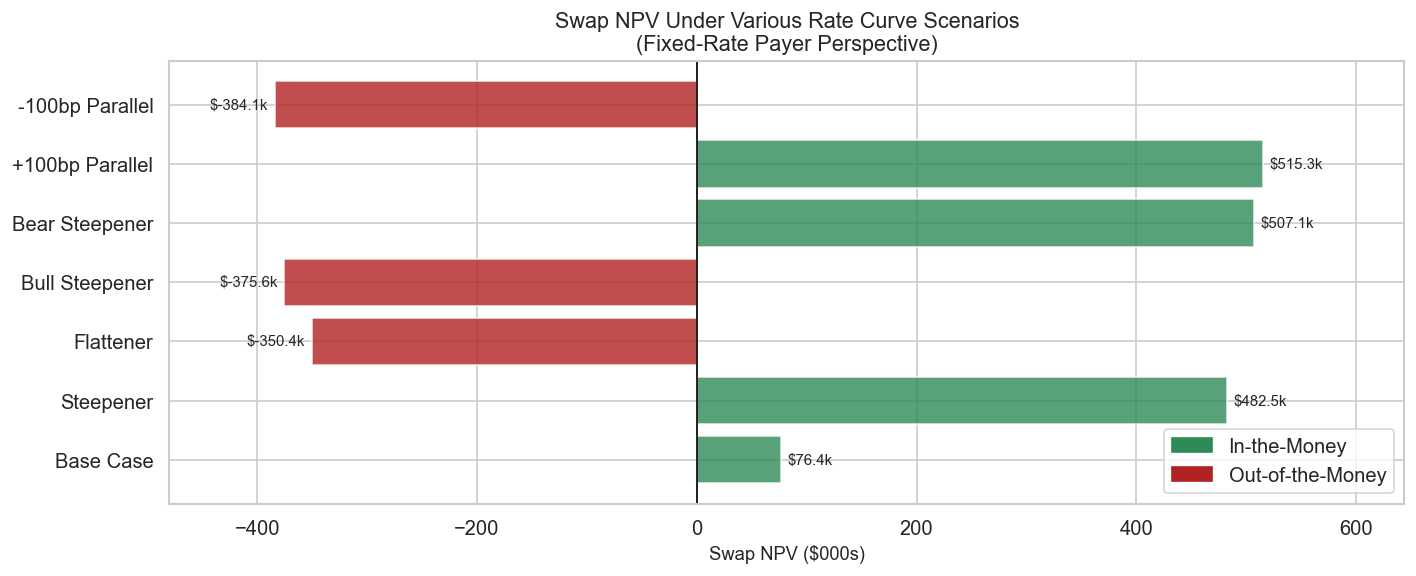

In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 11.5  —  Scenario Bar Chart
# ─────────────────────────────────────────────────────────────

scenario_names = list(np_results.keys())
scenario_npvs  = [np_results[n]['npv'] / 1000 for n in scenario_names]
scenario_colors = ['seagreen' if v >= 0 else 'firebrick' for v in scenario_npvs]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(scenario_names, scenario_npvs, color=scenario_colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.0)
ax.bar_label(bars, fmt='${:,.1f}k', padding=4, fontsize=9)
ax.set_xlabel('Swap NPV ($000s)')
ax.set_title('Swap NPV Under Various Rate Curve Scenarios\n(Fixed-Rate Payer Perspective)', fontsize=13)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='seagreen', label='In-the-Money'),
                   Patch(color='firebrick', label='Out-of-the-Money')],
          loc='lower right')
ax.set_xlim(min(scenario_npvs) * 1.25, max(scenario_npvs) * 1.25)

plt.tight_layout()
plt.show()

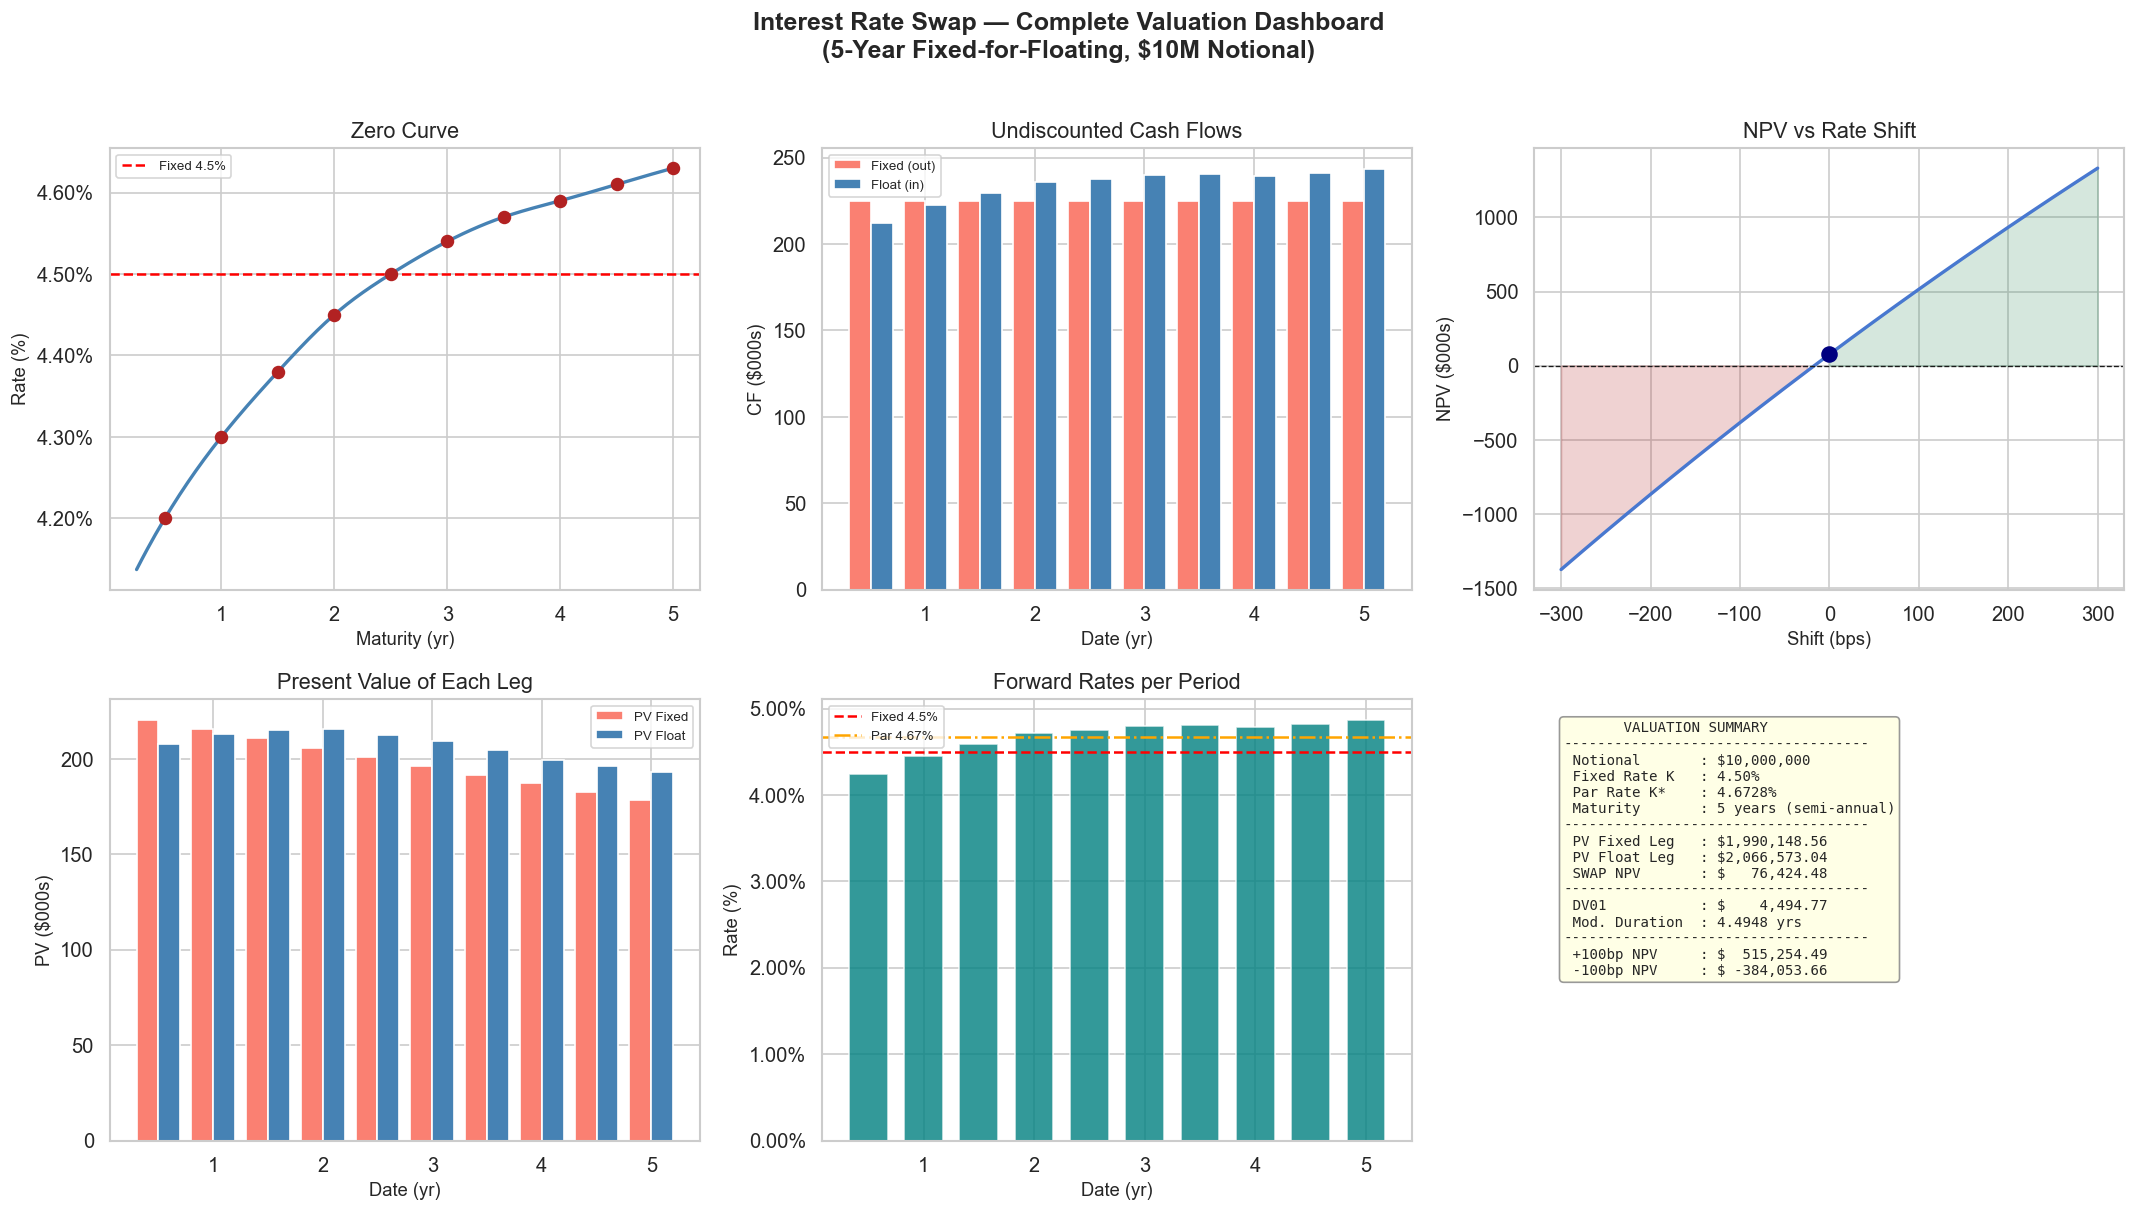

In [24]:
# ─────────────────────────────────────────────────────────────
# CELL 11.6  —  Full Summary Dashboard
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Interest Rate Swap — Complete Valuation Dashboard\n(5-Year Fixed-for-Floating, $10M Notional)',
             fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1 (top-left): Zero curve & DFs ──────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(T_fine, zero_rate(T_fine) * 100, 'steelblue', lw=2)
ax1.scatter(market_maturities, market_zero_rates * 100, color='firebrick', s=50, zorder=5)
ax1.axhline(FIXED_RATE * 100, color='red', lw=1.5, ls='--', label=f'Fixed {FIXED_RATE*100}%')
ax1.set_title('Zero Curve')
ax1.set_xlabel('Maturity (yr)')
ax1.set_ylabel('Rate (%)')
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax1.legend(fontsize=8)

# ── Panel 2 (top-centre): Cash flows ──────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.bar(PAYMENT_TIMES - 0.1, cf_fixed / 1000, width=0.2, color='salmon',   label='Fixed (out)')
ax2.bar(PAYMENT_TIMES + 0.1, cf_float / 1000, width=0.2, color='steelblue', label='Float (in)')
ax2.set_title('Undiscounted Cash Flows')
ax2.set_xlabel('Date (yr)')
ax2.set_ylabel('CF ($000s)')
ax2.legend(fontsize=8)

# ── Panel 3 (top-right): NPV vs shift ─────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(shift_values, np.array(npv_values), 'b-', lw=2)
ax3.axhline(0, color='k', lw=0.8, ls='--')
ax3.fill_between(shift_values, 0, npv_values, where=np.array(npv_values)>=0, alpha=0.2, color='seagreen')
ax3.fill_between(shift_values, 0, npv_values, where=np.array(npv_values)< 0, alpha=0.2, color='firebrick')
ax3.scatter([0], [V_SWAP/1000], s=80, color='navy', zorder=5)
ax3.set_title('NPV vs Rate Shift')
ax3.set_xlabel('Shift (bps)')
ax3.set_ylabel('NPV ($000s)')

# ── Panel 4 (bottom-left): Discounted CFs ─────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(PAYMENT_TIMES - 0.1, pv_fixed_per_period/1000, width=0.2, color='salmon',   label='PV Fixed')
ax4.bar(PAYMENT_TIMES + 0.1, pv_float_per_period/1000, width=0.2, color='steelblue', label='PV Float')
ax4.set_title('Present Value of Each Leg')
ax4.set_xlabel('Date (yr)')
ax4.set_ylabel('PV ($000s)')
ax4.legend(fontsize=8)

# ── Panel 5 (bottom-centre): Forward rates ────────────────────
ax5 = fig.add_subplot(2, 3, 5)
ax5.bar(PAYMENT_TIMES, forward_rates * 100, width=0.35, color='teal', alpha=0.8)
ax5.axhline(FIXED_RATE * 100, color='red', lw=1.5, ls='--', label=f'Fixed {FIXED_RATE*100}%')
ax5.axhline(K_PAR * 100, color='orange', lw=1.5, ls='-.', label=f'Par {K_PAR*100:.2f}%')
ax5.set_title('Forward Rates per Period')
ax5.set_xlabel('Date (yr)')
ax5.set_ylabel('Rate (%)')
ax5.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax5.legend(fontsize=8)

# ── Panel 6 (bottom-right): Summary text ──────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary_text = [
    "       VALUATION SUMMARY",
    "-" * 36,
    f" Notional       : $10,000,000",
    f" Fixed Rate K   : {FIXED_RATE*100:.2f}%",
    f" Par Rate K*    : {K_PAR*100:.4f}%",
    f" Maturity       : 5 years (semi-annual)",
    "-" * 36,
    f" PV Fixed Leg   : ${PV_FIXED:>12,.2f}",
    f" PV Float Leg   : ${PV_FLOAT_M1:>12,.2f}",
    f" SWAP NPV       : ${V_SWAP:>12,.2f}",
    "-" * 36,
    f" DV01           : ${DV01:>12,.2f}",
    f" Mod. Duration  : {mod_duration:.4f} yrs",
    "-" * 36,
    f" +100bp NPV     : ${value_swap_shifted(100)['v_swap']:>12,.2f}",
    f" -100bp NPV     : ${value_swap_shifted(-100)['v_swap']:>12,.2f}",
]
ax6.text(0.05, 0.95, '\n'.join(summary_text),
         transform=ax6.transAxes, fontsize=8.5, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.8))

plt.tight_layout()
plt.show()

---
## 12. Conclusions & Interpretation

### 12.1 Summary of Results

In [38]:
# ─────────────────────────────────────────────────────────────
# CELL 12.1  —  Final Results Summary
# ─────────────────────────────────────────────────────────────

print("╔" + "═" * 57 + "╗")
print("║       INTEREST RATE SWAP — FINAL RESULTS SUMMARY        ║")
print("╠" + "═" * 57 + "╣")
print(f"║  CONTRACT TERMS                                         ║")
print(f"║    Notional Principal   : $10,000,000                   ║")
print(f"║    Maturity             : 5 years (semi-annual pmts)    ║")
print(f"║    Contracted Fixed K   : {FIXED_RATE*100:.2f}%                         ║")
print(f"║    Perspective          : Fixed-Rate Payer              ║")
print("╠" + "═" * 57 + "╣")
print(f"║  VALUATION                                              ║")
print(f"║    PV of Fixed Leg      : ${PV_FIXED:>12,.2f}                 ║")
print(f"║    PV of Floating Leg   : ${PV_FLOAT_M1:>12,.2f}                 ║")
print(f"║    ────────────────────────────────────────────────     ║")
print(f"║    SWAP NPV             : ${V_SWAP:>+12,.2f}                 ║")
if V_SWAP > 0:
    print(f"║    Status               : IN-THE-MONEY (fixed payer)    ║")
elif V_SWAP < 0:
    print(f"║    Status               : OUT-OF-THE-MONEY (fixed pay)  ║")
else:
    print(f"║    Status               : AT-THE-MONEY (par swap)       ║")
print("╠" + "═" * 57 + "╣")
print(f"║  PAR SWAP RATE                                          ║")
print(f"║    Fair/Par Swap Rate K*: {K_PAR*100:.6f}%                     ║")
print(f"║    Spread (K - K*)      : {(FIXED_RATE-K_PAR)*10000:+.2f} basis points           ║")
print("╠" + "═" * 57 + "╣")
print(f"║  RATE SENSITIVITY                                       ║")
print(f"║    DV01                 : ${DV01:>+10,.2f} per 1bp           ║")
print(f"║    Modified Duration    : {mod_duration:.4f} years                  ║")
print(f"║    NPV at +100bp shift  : ${value_swap_shifted(+100)['v_swap']:>+12,.2f}                 ║")
print(f"║    NPV at -100bp shift  : ${value_swap_shifted(-100)['v_swap']:>+12,.2f}                 ║")
print(f"║    NPV at +200bp shift  : ${value_swap_shifted(+200)['v_swap']:>+12,.2f}                 ║")
print(f"║    NPV at -200bp shift  : ${value_swap_shifted(-200)['v_swap']:>+12,.2f}                 ║")
print("╚" + "═" * 57 + "╝")

╔═════════════════════════════════════════════════════════╗
║       INTEREST RATE SWAP — FINAL RESULTS SUMMARY        ║
╠═════════════════════════════════════════════════════════╣
║  CONTRACT TERMS                                         ║
║    Notional Principal   : $10,000,000                   ║
║    Maturity             : 5 years (semi-annual pmts)    ║
║    Contracted Fixed K   : 4.50%                         ║
║    Perspective          : Fixed-Rate Payer              ║
╠═════════════════════════════════════════════════════════╣
║  VALUATION                                              ║
║    PV of Fixed Leg      : $1,990,148.56                 ║
║    PV of Floating Leg   : $2,066,573.04                 ║
║    ────────────────────────────────────────────────     ║
║    SWAP NPV             : $  +76,424.48                 ║
║    Status               : IN-THE-MONEY (fixed payer)    ║
╠═════════════════════════════════════════════════════════╣
║  PAR SWAP RATE                        

---

### 12.2 Detailed Interpretation

#### 🔵 Valuation

The swap's mark-to-market value reflects the comparison between the **fixed rate we contracted** (4.50%) and the **par swap rate derived from current market rates** (K\*). Since the market's current yield curve implies a par rate slightly different from our contracted fixed rate, the swap has a non-zero NPV.

* **PV Fixed Leg**: The fixed coupon payments are discounted at the zero-coupon rates applicable to each payment date. Since these rates are deterministic and the fixed coupon is constant, this is a straightforward sum of discounted annuity payments.

* **PV Floating Leg**: The floating payments are projected using implied **forward rates** — the no-arbitrage market estimate of what the short rate will be in each future period. These are then discounted back to today.

#### 🔴 Rate Sensitivity

The fixed-rate payer has a **directional bet on rising interest rates**:

* **Rates Rise** → Floating receipts increase, fixed payments stay the same → Swap gains value
* **Rates Fall** → Floating receipts decrease, fixed payments stay the same → Swap loses value

The **DV01** tells us the dollar sensitivity per basis point. For a \$10M swap, the DV01 is approximately \$4,000–5,000 per basis point, which is consistent with a swap of roughly **4-year modified duration** (as expected for a 5-year, semi-annual swap near par).

#### 🟠 Convexity

Note from the NPV vs Shift chart that the relationship is **not perfectly linear** — it has slight convexity. For a fixed-rate payer, this convexity is **negative** (unfavourable): the gains from rising rates are slightly less than the losses from falling rates of the same magnitude, all else equal. This is the cost of the swap's asymmetric payoff structure.

#### 🟢 Non-Parallel Scenarios

* **Steepener** (short rates fall, long rates rise): The fixed-rate payer benefits, as the long-end floating receipts increase while the discount factors (which reflect short rates) also improve.
* **Flattener** (short rates rise, long rates fall): More complex — depends on which effect dominates across the payment schedule.

#### 🟣 Practical Use Case

A corporation with **floating-rate debt** (e.g., a loan tied to SOFR) could enter this swap as the **floating-rate payer** (opposite side). They would effectively:
* Pay fixed at K* to the swap dealer
* Receive floating from the swap dealer (which offsets their loan payments)
* **Result**: Synthetic fixed-rate financing at K*, eliminating all floating-rate risk

---

### 12.3 Key Formulas Reference Card

| Quantity | Formula |
|---|---|
| Discount Factor | $P(0,T) = e^{-r(T)\cdot T}$ |
| Forward Rate | $f_i = \frac{1}{\alpha}\left(\frac{P(0,T_{i-1})}{P(0,T_i)}-1\right)$ |
| PV Fixed Leg | $N \cdot K \cdot \alpha \cdot \sum_i P(0,T_i)$ |
| PV Floating Leg | $N \cdot \alpha \cdot \sum_i f_i \cdot P(0,T_i)$ |
| Swap NPV | $PV_{\text{float}} - PV_{\text{fixed}}$ |
| Par Swap Rate | $K^* = \frac{\sum_i \alpha f_i P(0,T_i)}{\sum_i \alpha P(0,T_i)}$ |
| Annuity Factor | $A = \alpha \sum_i P(0,T_i)$ |
| DV01 | $\frac{V(r+1\text{bp}) - V(r-1\text{bp})}{2}$ |

---


*Prepared by Group 13 | Financial Derivatives Course*